# Phase 1 — Data Cleaning (`application_train.csv`)

This notebook **is** the cleaning pipeline. Run it top to bottom. It writes:

- `data/processed/train_clean.parquet`
- `data/processed/split_indices.npz`
- `reports/data_quality_report.md`
- `reports/cleaning_summary.md`

Later notebooks (`01_eda`, `02_feature_selection`, `03_model_building`) **load** those files. They do not re-clean.

**Plan (run in this order):**

1. Load the raw CSV and check shape / target rate.
2. Profile dtypes and missingness (decide what to drop).
3. Replace the `DAYS_EMPLOYED == 365243` sentinel with NaN.
4. Drop columns with **> 60%** missing.
5. Impute: numeric **median**, categorical **`'MISSING'`**.
6. Encode: one-hot if ≤ 10 unique values, **frequency** if more.
7. Stratified **70 / 15 / 15** split on `TARGET`.
8. `StandardScaler` **fit on train only**, apply to all rows.
9. Save parquet + reports.

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import os
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def resolve_repo_root() -> Path:
    env = os.environ.get("CREDIT_RISK_REPO_ROOT")
    if env:
        return Path(env).expanduser().resolve()
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / "src" / "data" / "clean.py").is_file() and (
            candidate / "notebooks"
        ).is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not locate the repo root from the current working directory. "
        "Set CREDIT_RISK_REPO_ROOT to the clone path."
    )


REPO_ROOT = resolve_repo_root()
RAW_CSV = REPO_ROOT / ".home-credit-default-risk" / "application_train.csv"
PARQUET = REPO_ROOT / "data" / "processed" / "train_clean.parquet"
INDICES = REPO_ROOT / "data" / "processed" / "split_indices.npz"
QUALITY_MD = REPO_ROOT / "reports" / "data_quality_report.md"
SUMMARY_MD = REPO_ROOT / "reports" / "cleaning_summary.md"
FIG_DIR = REPO_ROOT / "reports" / "figures"

PARQUET.parent.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
QUALITY_MD.parent.mkdir(parents=True, exist_ok=True)

EXPECTED_SHAPE = (307_511, 122)
DROP_MISSING_THRESHOLD = 0.60
HIGH_CARDINALITY_THRESHOLD = 10
DAYS_EMPLOYED_SENTINEL = 365_243
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15
RANDOM_STATE = 42
NON_FEATURE_COLS = ("SK_ID_CURR", "TARGET", "SPLIT")

PALETTE = {
    "bg": "#0A1428",
    "panel": "#10203D",
    "mint": "#00D9B5",
    "blue": "#3B82F6",
    "red": "#F87171",
    "body": "#CBD5E1",
    "white": "#FFFFFF",
    "muted": "#94A3B8",
}
mpl.rcParams.update({
    "figure.facecolor": PALETTE["bg"],
    "axes.facecolor": PALETTE["panel"],
    "axes.edgecolor": PALETTE["muted"],
    "axes.labelcolor": PALETTE["body"],
    "axes.titlecolor": PALETTE["white"],
    "xtick.color": PALETTE["body"],
    "ytick.color": PALETTE["body"],
    "text.color": PALETTE["body"],
    "savefig.facecolor": PALETTE["bg"],
    "savefig.dpi": 130,
    "font.size": 11,
})

print("REPO_ROOT:", REPO_ROOT)
print("RAW_CSV exists:", RAW_CSV.exists(), "→", RAW_CSV)

REPO_ROOT: F:\Git Repo\DA Lab Project
RAW_CSV exists: True → F:\Git Repo\DA Lab Project\.home-credit-default-risk\application_train.csv


## 1. Load raw data

Home Credit `application_train.csv` only (other tables are out of scope). We assert the official shape so a wrong file fails immediately.

In [2]:
if not RAW_CSV.exists():
    raise FileNotFoundError(
        f"Place application_train.csv at {RAW_CSV}"
    )

df_raw = pd.read_csv(RAW_CSV)
if df_raw.shape != EXPECTED_SHAPE:
    raise ValueError(
        f"Unexpected shape {df_raw.shape}; expected {EXPECTED_SHAPE}."
    )

df = df_raw.copy()
print(f"Loaded {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"TARGET default rate: {df['TARGET'].mean():.4%}")
print(f"Dtypes: int={(df.dtypes.astype(str).str.startswith('int')).sum()}, "
      f"float={(df.dtypes.astype(str).str.startswith('float')).sum()}, "
      f"object={(df.dtypes == 'object').sum()}")
df.head()

Loaded 307,511 rows × 122 columns
TARGET default rate: 8.0729%
Dtypes: int=41, float=65, object=16


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Data-quality profile

Rank columns by missingness. Anything **above 60%** is a drop candidate: imputing it would invent most of the column. We keep fields at or below 60% (e.g. `LANDAREA_*` ≈ 59%) and impute those later.

Columns with > 60% missing: 17


,missing_frac
COMMONAREA_AVG,69.87%
COMMONAREA_MODE,69.87%
COMMONAREA_MEDI,69.87%
NONLIVINGAPARTMENTS_MEDI,69.43%
NONLIVINGAPARTMENTS_MODE,69.43%
NONLIVINGAPARTMENTS_AVG,69.43%
FONDKAPREMONT_MODE,68.39%
LIVINGAPARTMENTS_AVG,68.35%
LIVINGAPARTMENTS_MEDI,68.35%
LIVINGAPARTMENTS_MODE,68.35%


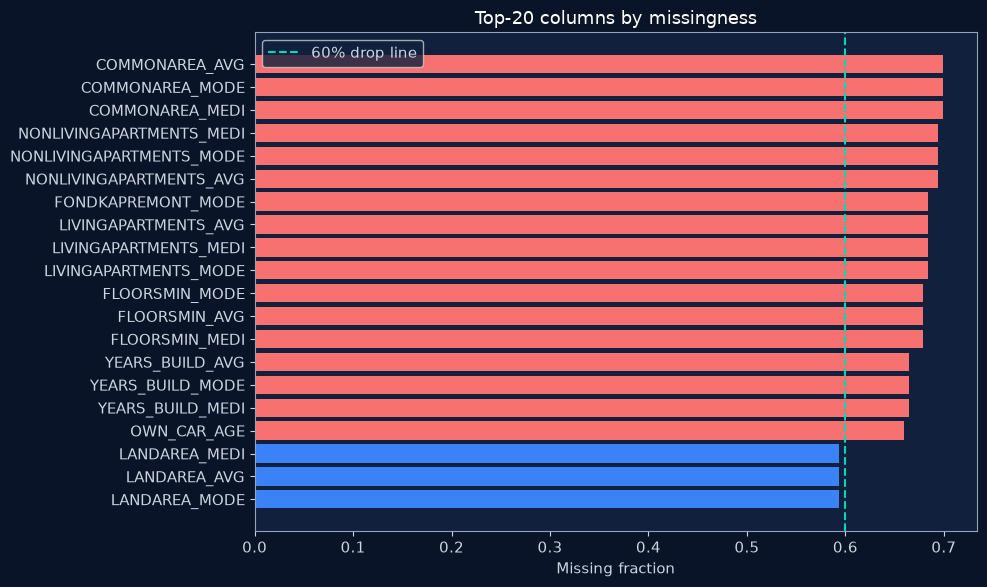

In [3]:
missing_pct = df.isna().mean().sort_values(ascending=False)
high_missing = missing_pct[missing_pct > DROP_MISSING_THRESHOLD]

print(f"Columns with > {DROP_MISSING_THRESHOLD:.0%} missing: {len(high_missing)}")
display(high_missing.to_frame("missing_frac").style.format("{:.2%}"))

top20 = missing_pct.head(20)
fig, ax = plt.subplots(figsize=(10, 6))
colors = [PALETTE["red"] if v > DROP_MISSING_THRESHOLD else PALETTE["blue"] for v in top20.values]
ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1])
ax.axvline(DROP_MISSING_THRESHOLD, color=PALETTE["mint"], linestyle="--", label="60% drop line")
ax.set_xlabel("Missing fraction")
ax.set_title("Top-20 columns by missingness")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "00_missingness_top20.png")
plt.show()

In [4]:
def _dtype_family(dtype) -> str:
    name = str(dtype)
    if name.startswith("int"):
        return "int"
    if name.startswith("float"):
        return "float"
    if name == "object":
        return "object"
    if name == "bool":
        return "bool"
    return "other"

dtype_counts = df.dtypes.map(_dtype_family).value_counts().to_dict()

lines = [
    "# Data Quality Report — application_train.csv",
    "",
    "Generated by `notebooks/00_data_cleaning.ipynb` (Phase 1).",
    "",
    "## 1. Shape",
    "",
    f"- Rows: **{df.shape[0]:,}**",
    f"- Columns: **{df.shape[1]}**",
    "",
    "## 2. Dtype Breakdown",
    "",
    "| Dtype family | Column count |",
    "|---|---|",
]
for fam in ("int", "float", "object", "bool", "other"):
    lines.append(f"| {fam} | {dtype_counts.get(fam, 0)} |")

lines += [
    "",
    "## 3. Top 20 Columns by Missing Fraction",
    "",
    "| Rank | Column | Missing % |",
    "|---|---|---|",
]
for i, (col, frac) in enumerate(missing_pct.head(20).items(), start=1):
    lines.append(f"| {i} | `{col}` | {frac:.2%} |")

lines += [
    "",
    f"## 4. Columns with >{DROP_MISSING_THRESHOLD:.0%} Missing (Flagged for Drop)",
    "",
    f"**{len(high_missing)} column(s)** exceed the threshold:",
    "",
]
for col, frac in high_missing.items():
    lines.append(f"- `{col}` — {frac:.2%} missing")

lines += [
    "",
    "## 5. Target Distribution",
    "",
    f"- Default rate: **{df['TARGET'].mean():.4%}**",
    f"- Class counts: 0 = {(df['TARGET'] == 0).sum():,}, 1 = {(df['TARGET'] == 1).sum():,}",
    "",
]
QUALITY_MD.write_text("\n".join(lines), encoding="utf-8")
print("Wrote", QUALITY_MD)

Wrote F:\Git Repo\DA Lab Project\reports\data_quality_report.md


## 3. Fix the `DAYS_EMPLOYED` sentinel

Home Credit codes “no / unknown employment” as **365243** days (~1000 years). If we leave it, any model that uses employment length treats those people as ancient employees.

**We do not drop those rows** (~18% of the file). We set the value to NaN and impute it with the rest of the numeric gaps.

In [5]:
n_sentinel = int((df["DAYS_EMPLOYED"] == DAYS_EMPLOYED_SENTINEL).sum())
print(f"DAYS_EMPLOYED == {DAYS_EMPLOYED_SENTINEL}: {n_sentinel:,} rows "
      f"({n_sentinel / len(df):.1%})")

df.loc[df["DAYS_EMPLOYED"] == DAYS_EMPLOYED_SENTINEL, "DAYS_EMPLOYED"] = np.nan
print("Remaining sentinel values:", int((df["DAYS_EMPLOYED"] == DAYS_EMPLOYED_SENTINEL).sum()))
print("DAYS_EMPLOYED NaNs now:", int(df["DAYS_EMPLOYED"].isna().sum()))

DAYS_EMPLOYED == 365243: 55,374 rows (18.0%)
Remaining sentinel values: 0
DAYS_EMPLOYED NaNs now: 55374


## 4. Drop columns with > 60% missing

Most of these are housing AVG / MODE / MEDI triples (`COMMONAREA_*`, `LIVINGAPARTMENTS_*`, …) plus `OWN_CAR_AGE`. Filling 70% of a column with a median would create a mostly-fake feature.

In [6]:
missing_frac = df.isna().mean()
to_drop = missing_frac[missing_frac > DROP_MISSING_THRESHOLD].index.tolist()
dropped_log = [{"column": c, "missing_pct": float(missing_frac[c])} for c in to_drop]

print(f"Dropping {len(to_drop)} columns:")
for entry in dropped_log:
    print(f"  {entry['column']:32s}  {entry['missing_pct']:.2%}")

df = df.drop(columns=to_drop)
print(f"Shape after drop: {df.shape}")

Dropping 17 columns:
  OWN_CAR_AGE                       65.99%
  YEARS_BUILD_AVG                   66.50%
  COMMONAREA_AVG                    69.87%
  FLOORSMIN_AVG                     67.85%
  LIVINGAPARTMENTS_AVG              68.35%
  NONLIVINGAPARTMENTS_AVG           69.43%
  YEARS_BUILD_MODE                  66.50%
  COMMONAREA_MODE                   69.87%
  FLOORSMIN_MODE                    67.85%
  LIVINGAPARTMENTS_MODE             68.35%
  NONLIVINGAPARTMENTS_MODE          69.43%
  YEARS_BUILD_MEDI                  66.50%
  COMMONAREA_MEDI                   69.87%
  FLOORSMIN_MEDI                    67.85%
  LIVINGAPARTMENTS_MEDI             68.35%
  NONLIVINGAPARTMENTS_MEDI          69.43%
  FONDKAPREMONT_MODE                68.39%
Shape after drop: (307511, 105)


## 5. Impute remaining NaNs

| Type | Method | Why not the alternative |
|---|---|---|
| Numeric | **column median** | Mean is pulled by long-tailed income/credit. KNN/MICE is slow and leaks if fit on all rows. |
| Categorical | literal **`'MISSING'`** | Mode pretends we know the category. Missingness can itself be a signal. |

In [7]:
fill_counts = {}
for col in df.columns:
    n_missing = int(df[col].isna().sum())
    if n_missing == 0:
        continue
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna("MISSING")
    fill_counts[col] = n_missing

print(f"Filled {len(fill_counts)} columns. Remaining NaNs: {int(df.isna().sum().sum())}")
print("Largest fills:")
for col, n in sorted(fill_counts.items(), key=lambda kv: -kv[1])[:12]:
    print(f"  {col:40s}  {n:,}")

Filled 51 columns. Remaining NaNs: 0
Largest fills:
  LANDAREA_AVG                              182,590
  LANDAREA_MODE                             182,590
  LANDAREA_MEDI                             182,590
  BASEMENTAREA_AVG                          179,943
  BASEMENTAREA_MODE                         179,943
  BASEMENTAREA_MEDI                         179,943
  EXT_SOURCE_1                              173,378
  NONLIVINGAREA_AVG                         169,682
  NONLIVINGAREA_MODE                        169,682
  NONLIVINGAREA_MEDI                        169,682
  ELEVATORS_AVG                             163,891
  ELEVATORS_MODE                            163,891


## 6. Encode categoricals

- **≤ 10 unique values** → one-hot (`drop_first=True` so linear models are not dummy-trapped).
- **> 10 unique values** → **frequency encoding** (category → how often it appears). That is `OCCUPATION_TYPE` and `ORGANIZATION_TYPE`.

We do **not** one-hot the high-cardinality fields (too many columns) and we do **not** target-encode (that can leak `TARGET` into features unless you use nested CV).

In [8]:
cat_cols = [c for c in df.select_dtypes(include="object").columns]
print("Object columns:", cat_cols)
print({c: int(df[c].nunique(dropna=False)) for c in cat_cols})

high_card = [c for c in cat_cols if df[c].nunique(dropna=False) > HIGH_CARDINALITY_THRESHOLD]
low_card = [c for c in cat_cols if c not in high_card]
print("Frequency-encode:", high_card)
print("One-hot:", low_card)

for col in high_card:
    counts = df[col].value_counts(dropna=False)
    df[col] = df[col].map(counts).astype(float)

df = pd.get_dummies(df, columns=low_card, drop_first=True)

bool_cols = df.select_dtypes(include="bool").columns
for col in bool_cols:
    df[col] = df[col].astype(float)

print(f"Shape after encoding: {df.shape}")

Object columns: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


{'NAME_CONTRACT_TYPE': 2, 'CODE_GENDER': 3, 'FLAG_OWN_CAR': 2, 'FLAG_OWN_REALTY': 2, 'NAME_TYPE_SUITE': 8, 'NAME_INCOME_TYPE': 8, 'NAME_EDUCATION_TYPE': 5, 'NAME_FAMILY_STATUS': 6, 'NAME_HOUSING_TYPE': 6, 'OCCUPATION_TYPE': 19, 'WEEKDAY_APPR_PROCESS_START': 7, 'ORGANIZATION_TYPE': 58, 'HOUSETYPE_MODE': 4, 'WALLSMATERIAL_MODE': 8, 'EMERGENCYSTATE_MODE': 3}


Frequency-encode: ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE']
One-hot: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


Shape after encoding: (307511, 143)


## 7. Stratified 70 / 15 / 15 split

Defaults are only ~8%. A random split can starve val/test of positives. We stratify on `TARGET`, seed **42**, and store the assignment in a `SPLIT` column so every later notebook uses the **same** rows.

In [9]:
assert "TARGET" in df.columns
n_rows = len(df)
y = df["TARGET"]

pool_frac = VAL_FRAC + TEST_FRAC
train_idx, pool_idx, _, _ = train_test_split(
    np.arange(n_rows),
    y.values,
    train_size=TRAIN_FRAC,
    test_size=pool_frac,
    stratify=y.values,
    random_state=RANDOM_STATE,
)
val_frac_of_pool = VAL_FRAC / pool_frac
val_idx, test_idx, _, _ = train_test_split(
    pool_idx,
    y.values[pool_idx],
    train_size=val_frac_of_pool,
    test_size=1 - val_frac_of_pool,
    stratify=y.values[pool_idx],
    random_state=RANDOM_STATE,
)

train_mask = np.zeros(n_rows, dtype=bool)
val_mask = np.zeros(n_rows, dtype=bool)
test_mask = np.zeros(n_rows, dtype=bool)
train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True
assert int(train_mask.sum() + val_mask.sum() + test_mask.sum()) == n_rows

split_col = np.full(n_rows, "", dtype=object)
split_col[train_mask] = "train"
split_col[val_mask] = "val"
split_col[test_mask] = "test"

for name, mask in (("train", train_mask), ("val", val_mask), ("test", test_mask)):
    print(
        f"{name:5s}  n={mask.sum():7,}  "
        f"default rate={y.values[mask].mean():.4%}"
    )

train  n=215,257  default rate=8.0727%
val    n= 46,127  default rate=8.0734%
test   n= 46,127  default rate=8.0734%


## 8. Standardize — fit on **train** only

Trees do not need this. Logistic regression and the MLP do. We fit `StandardScaler` on the **train mask** so val/test means never leak into the transform. `SK_ID_CURR` and `TARGET` are left unscaled.

In [10]:
feature_cols = [
    c for c in df.columns
    if c not in NON_FEATURE_COLS and pd.api.types.is_numeric_dtype(df[c])
]

for col in feature_cols:
    if pd.api.types.is_integer_dtype(df[col]):
        df[col] = df[col].astype(float)

scaler = StandardScaler()
scaler.fit(df.loc[train_mask, feature_cols])
df.loc[:, feature_cols] = scaler.transform(df[feature_cols])
df["SPLIT"] = split_col

print(f"Scaled {len(feature_cols)} numeric feature columns")
print(f"Train-slice mean of first 5 features (should be ~0):")
print(df.loc[train_mask, feature_cols[:5]].mean().round(4).to_string())
print(f"Final shape: {df.shape}")

Scaled 141 numeric feature columns
Train-slice mean of first 5 features (should be ~0):
CNT_CHILDREN        0.0
AMT_INCOME_TOTAL    0.0
AMT_CREDIT          0.0
AMT_ANNUITY        -0.0
AMT_GOODS_PRICE    -0.0
Final shape: (307511, 144)


## 9. Save artifacts

`01_eda.ipynb` reads this parquet as `df_clean`.

In [11]:
df.to_parquet(PARQUET, index=False)
np.savez(
    INDICES,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask,
    target=df["TARGET"].values,
)

summary = [
    "# Cleaning Summary — application_train.csv",
    "",
    "Generated by `notebooks/00_data_cleaning.ipynb` (Phase 1).",
    "",
    "## Shape",
    "",
    f"- Rows in: **{EXPECTED_SHAPE[0]:,}**, columns in: **{EXPECTED_SHAPE[1]}**",
    f"- Rows out: **{df.shape[0]:,}**, columns out: **{df.shape[1]}**",
    f"- Numeric feature columns (post-encoding): **{len(feature_cols)}**",
    "",
    "## DAYS_EMPLOYED sentinel replaced",
    "",
    f"- Rows where `DAYS_EMPLOYED == {DAYS_EMPLOYED_SENTINEL}` were set to NaN: **{n_sentinel:,}**",
    "",
    f"## Columns dropped (> {DROP_MISSING_THRESHOLD:.0%} missing)",
    "",
    f"**{len(dropped_log)} column(s) dropped:**",
    "",
    "| Column | Missing % |",
    "|---|---|",
]
for entry in dropped_log:
    summary.append(f"| `{entry['column']}` | {entry['missing_pct']:.2%} |")

summary += [
    "",
    "## Encoding",
    "",
    f"- One-hot encoded ({len(low_card)} columns): {', '.join(f'`{c}`' for c in low_card)}",
    f"- Frequency encoded ({len(high_card)} columns): {', '.join(f'`{c}`' for c in high_card)}",
    "",
    "## Stratified split",
    "",
    f"- Train: **{int(train_mask.sum()):,}**",
    f"- Val:   **{int(val_mask.sum()):,}**",
    f"- Test:  **{int(test_mask.sum()):,}**",
    "",
    "## Imputation",
    "",
    f"- Columns with NaNs filled: **{len(fill_counts)}**",
    "- Numeric: column median. Categorical: literal `'MISSING'`.",
    "",
]
SUMMARY_MD.write_text("\n".join(summary), encoding="utf-8")

print("Wrote", PARQUET, f"({PARQUET.stat().st_size / 1e6:.1f} MB)")
print("Wrote", INDICES)
print("Wrote", SUMMARY_MD)
print(df["SPLIT"].value_counts())

Wrote F:\Git Repo\DA Lab Project\data\processed\train_clean.parquet (22.9 MB)
Wrote F:\Git Repo\DA Lab Project\data\processed\split_indices.npz
Wrote F:\Git Repo\DA Lab Project\reports\cleaning_summary.md
SPLIT
train    215257
val       46127
test      46127
Name: count, dtype: int64


## 10. Sanity checks

Reload the parquet and confirm: no leftover sentinels, no NaNs, three splits, train features centered.

In [12]:
check = pd.read_parquet(PARQUET)
print("Reloaded:", check.shape)
print("NaNs:", int(check.isna().sum().sum()))
print("SPLIT counts:\n", check["SPLIT"].value_counts().to_string())

if "DAYS_EMPLOYED" in check.columns:
    print("Sentinel still present:", int((check["DAYS_EMPLOYED"] == DAYS_EMPLOYED_SENTINEL).sum()))

feat = [c for c in feature_cols if c in check.columns][:8]
print("Train means (≈ 0):")
print(check.loc[check["SPLIT"] == "train", feat].mean().round(4).to_string())
print("Done. Next: notebooks/01_eda.ipynb")

Reloaded: (307511, 144)
NaNs: 0
SPLIT counts:
 SPLIT
train    215257
val       46127
test      46127
Sentinel still present: 0
Train means (≈ 0):
CNT_CHILDREN                  0.0
AMT_INCOME_TOTAL              0.0
AMT_CREDIT                    0.0
AMT_ANNUITY                  -0.0
AMT_GOODS_PRICE              -0.0
REGION_POPULATION_RELATIVE   -0.0
DAYS_BIRTH                    0.0
DAYS_EMPLOYED                 0.0
Done. Next: notebooks/01_eda.ipynb
